In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("uber_processed.csv")
df.head()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,bearing,pickup_dist_from_center,dropoff_dist_from_center,hour,day_of_week,month,year,is_weekend,is_rush_hour
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,179.124609,2.888822,1.280903,19,3,5,2015,0,1
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,359.302804,1.976096,4.279659,20,4,7,2009,0,0
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,45.254124,3.111167,7.594400,21,0,8,2009,0,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,33.192997,9.035634,10.635729,8,4,6,2009,0,1
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,295.254931,7.659096,6.059087,17,3,8,2014,0,1


**DROPPING LONG & LAT FEATURES FOR LINEAR MODELS**

- 1) Since we already calculated trip-distance, bearing and pickup distance, we will be dropping the long and lat features for linear models as linear models do not handle redundant features well as it might cause co-linearity between features which could cause unstable model coefficients fluctuating randomly even with minor changes in data

- 2) Multi-Linear regression fits a flat ,  multi - dimenstional plane through your data,  it is mathematically impossible to represent a peak in the middle ( mid of the city ) that then inclines as we head other directions.
- 3) Poly-Regression would introudce severe multi-collinearity between data like lat and lat^2, and could overfit the data


In [3]:
df = df.drop(columns=['pickup_longitude', 'pickup_latitude', 
                       'dropoff_longitude', 'dropoff_latitude'])
df.head()

,fare_amount,passenger_count,trip_distance_km,bearing,pickup_dist_from_center,dropoff_dist_from_center,hour,day_of_week,month,year,is_weekend,is_rush_hour
0,7.5,1,1.683323,179.124609,2.888822,1.280903,19,3,5,2015,0,1
1,7.7,1,2.457590,359.302804,1.976096,4.279659,20,4,7,2009,0,0
2,12.9,1,5.036377,45.254124,3.111167,7.594400,21,0,8,2009,0,0
3,5.3,3,1.661683,33.192997,9.035634,10.635729,8,4,6,2009,0,1
4,16.0,5,4.475450,295.254931,7.659096,6.059087,17,3,8,2014,0,1


VISUALIZING FEATURES VS. THE LABEL

Baseline Assessment: We plot all features against the label individually to get a baseline sense of which features might require a higher-degree polynomial like  a quadratic curve or parabola) to be modeled accurately

Limitations of 1D Analysis: While these plots do not capture complex interaction effects ( how two features like distance and time might multiply together to affect the price), they give us a solid verdict on a feature's standalone behavior. If a feature does not show a curved relationship on its own, we can confidently treat it as a linear feature (Degree 1) for our baseline model

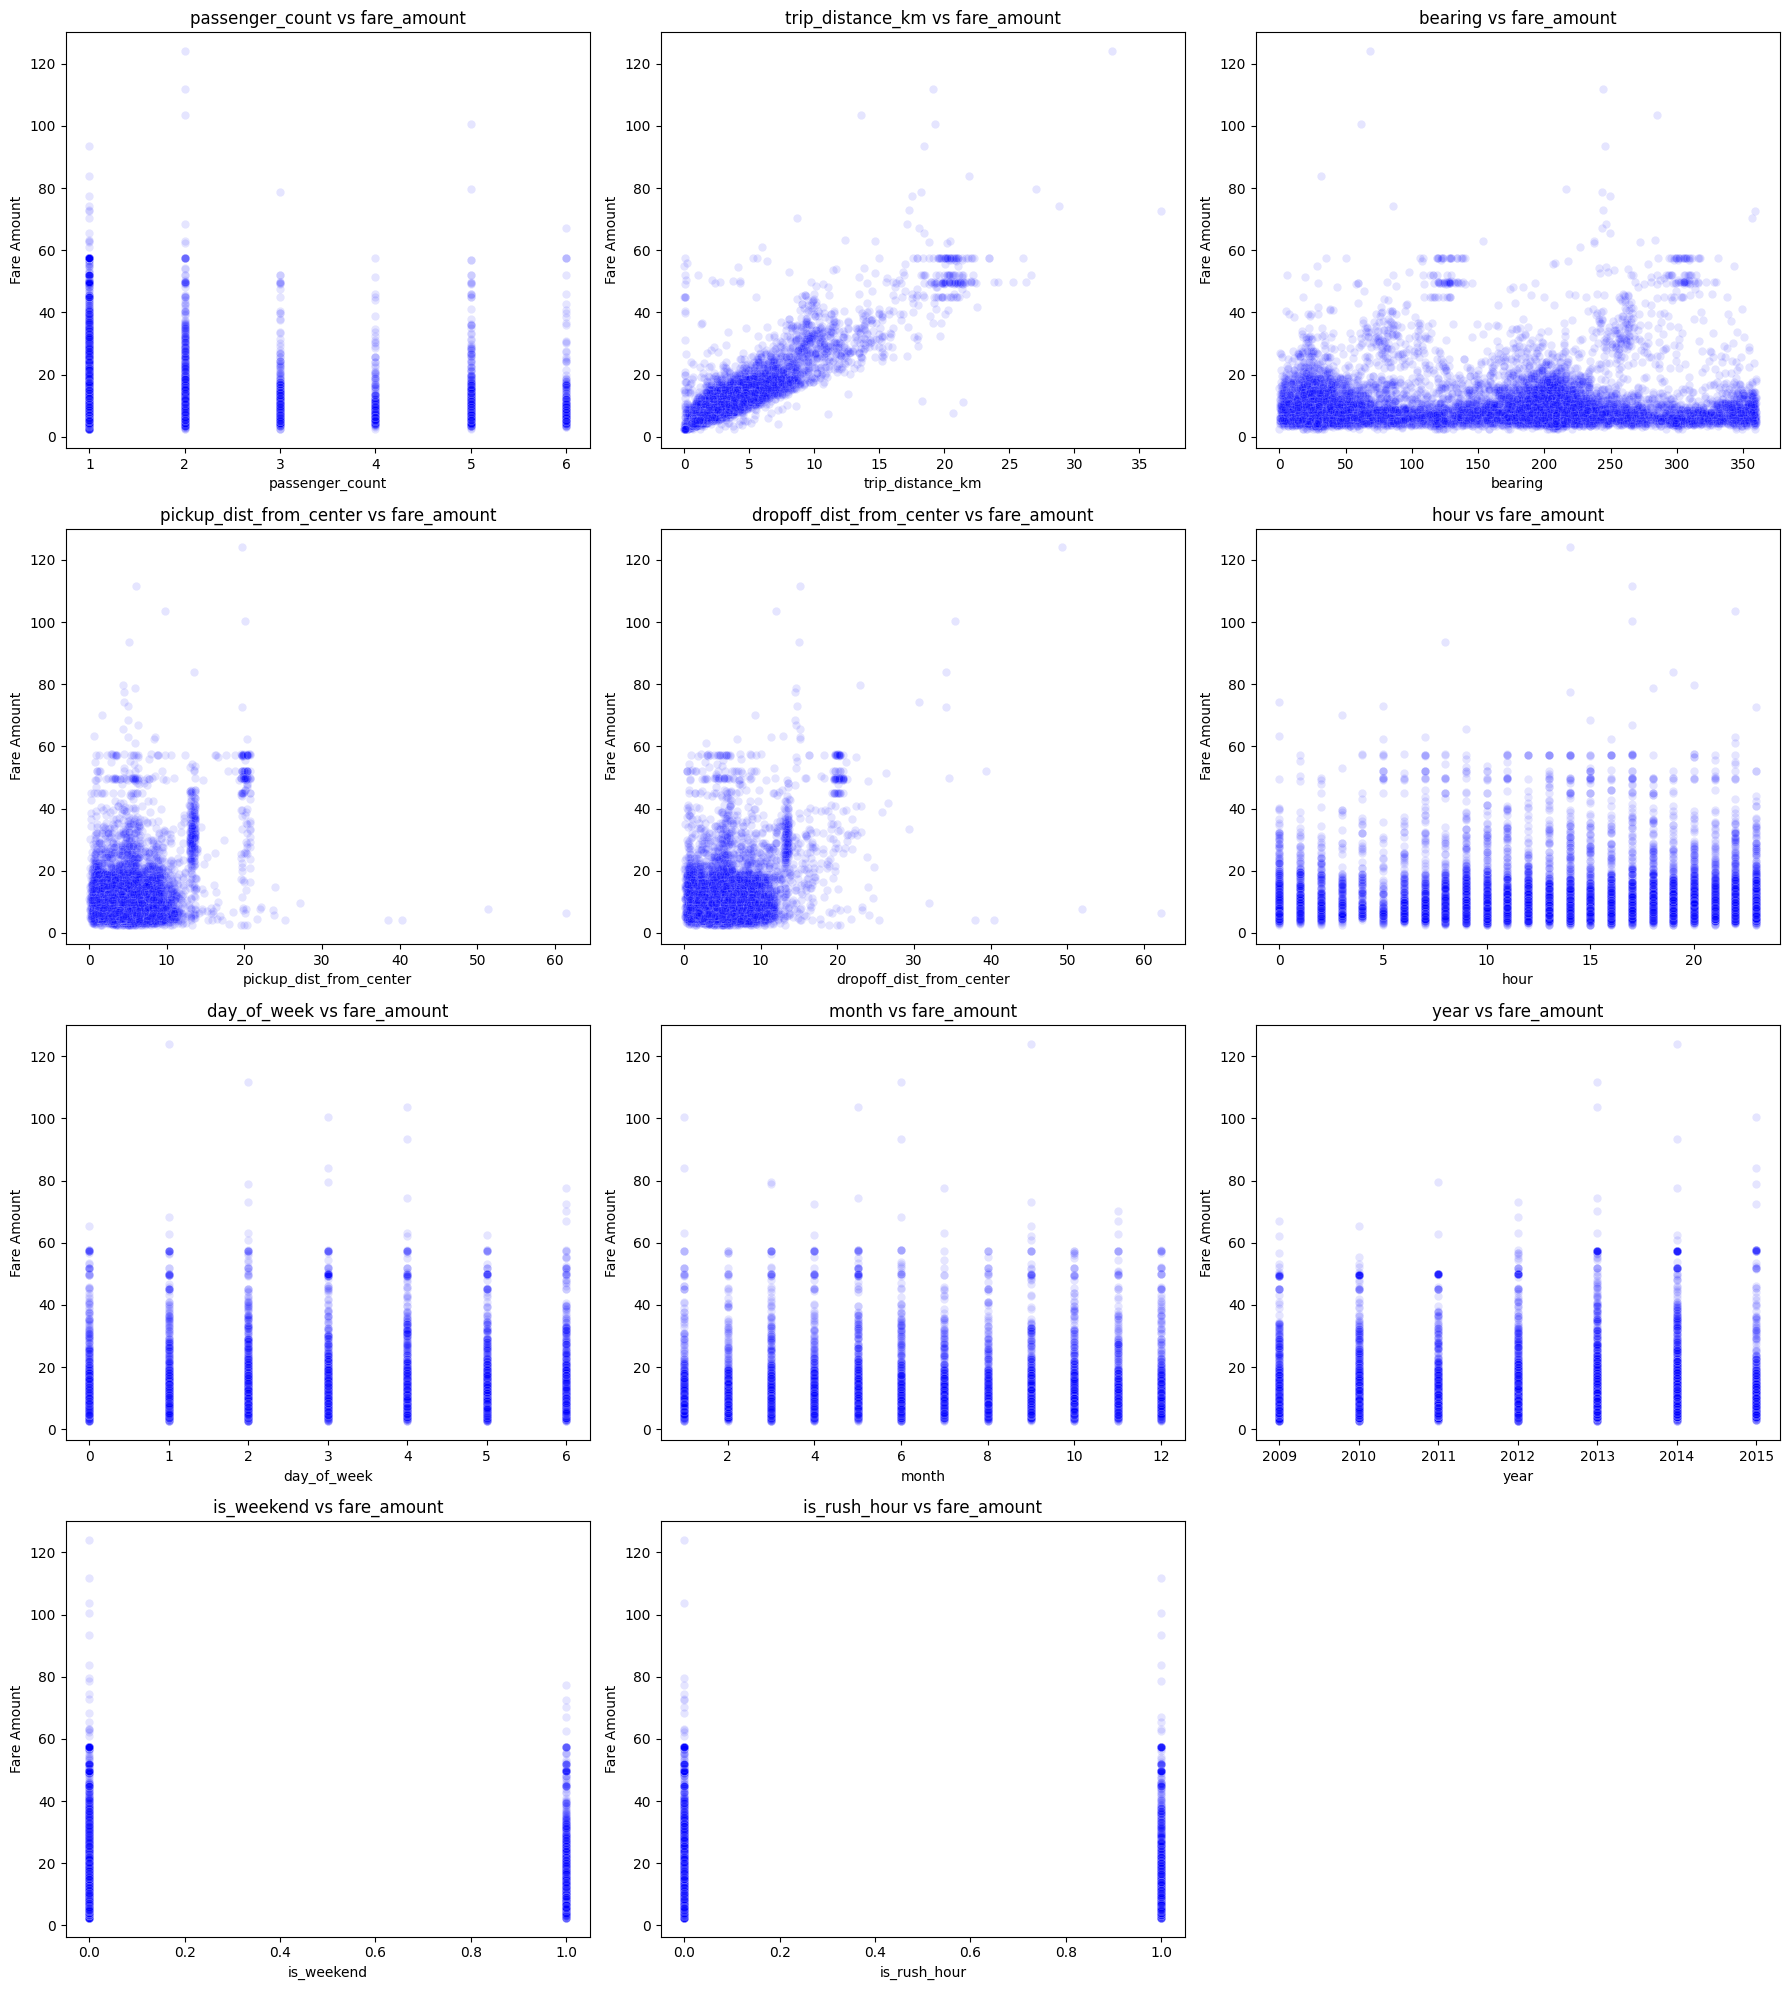

In [4]:
df_sample = df.sample(n=10000, random_state=42) if len(df) > 10000 else df 
target = 'fare_amount'
features = [col for col in df.columns if col != target]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # flatten the 2D array of axes for easy iteration

for i, feature in enumerate(features):
  
    sns.scatterplot(data=df_sample, x=feature, y=target, alpha=0.1, ax=axes[i], color='blue')
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_ylabel('Fare Amount')
    axes[i].set_xlabel(feature)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**We will also remove the day of week feature and sperate it into 7 binary feaures**

- meaning if a trip hapened on day 4 that would trigger the feauter called is_friday would be one and  all other features named is_Xday would be 0 

- best way to implement this is through pandas mapping


In [5]:
day_mapping = {
    0: 'monday', 
    1: 'tuesday', 
    2: 'wednesday', 
    3: 'thursday', 
    4: 'friday', 
    5: 'saturday', 
    6: 'sunday'
}
df['day_name']  = df['day_of_week'].map(day_mapping) #this creates a temp column with text names
df = pd.get_dummies( df, columns=['day_name'], prefix = 'is', dtype = int )
df = df.drop( columns = ['day_of_week'] )
df.head()



,fare_amount,passenger_count,trip_distance_km,bearing,pickup_dist_from_center,dropoff_dist_from_center,hour,month,year,is_weekend,is_rush_hour,is_friday,is_monday,is_saturday,is_sunday,is_thursday,is_tuesday,is_wednesday
0,7.5,1,1.683323,179.124609,2.888822,1.280903,19,5,2015,0,1,0,0,0,0,1,0,0
1,7.7,1,2.457590,359.302804,1.976096,4.279659,20,7,2009,0,0,1,0,0,0,0,0,0
2,12.9,1,5.036377,45.254124,3.111167,7.594400,21,8,2009,0,0,0,1,0,0,0,0,0
3,5.3,3,1.661683,33.192997,9.035634,10.635729,8,6,2009,0,1,1,0,0,0,0,0,0
4,16.0,5,4.475450,295.254931,7.659096,6.059087,17,8,2014,0,1,0,0,0,0,1,0,0


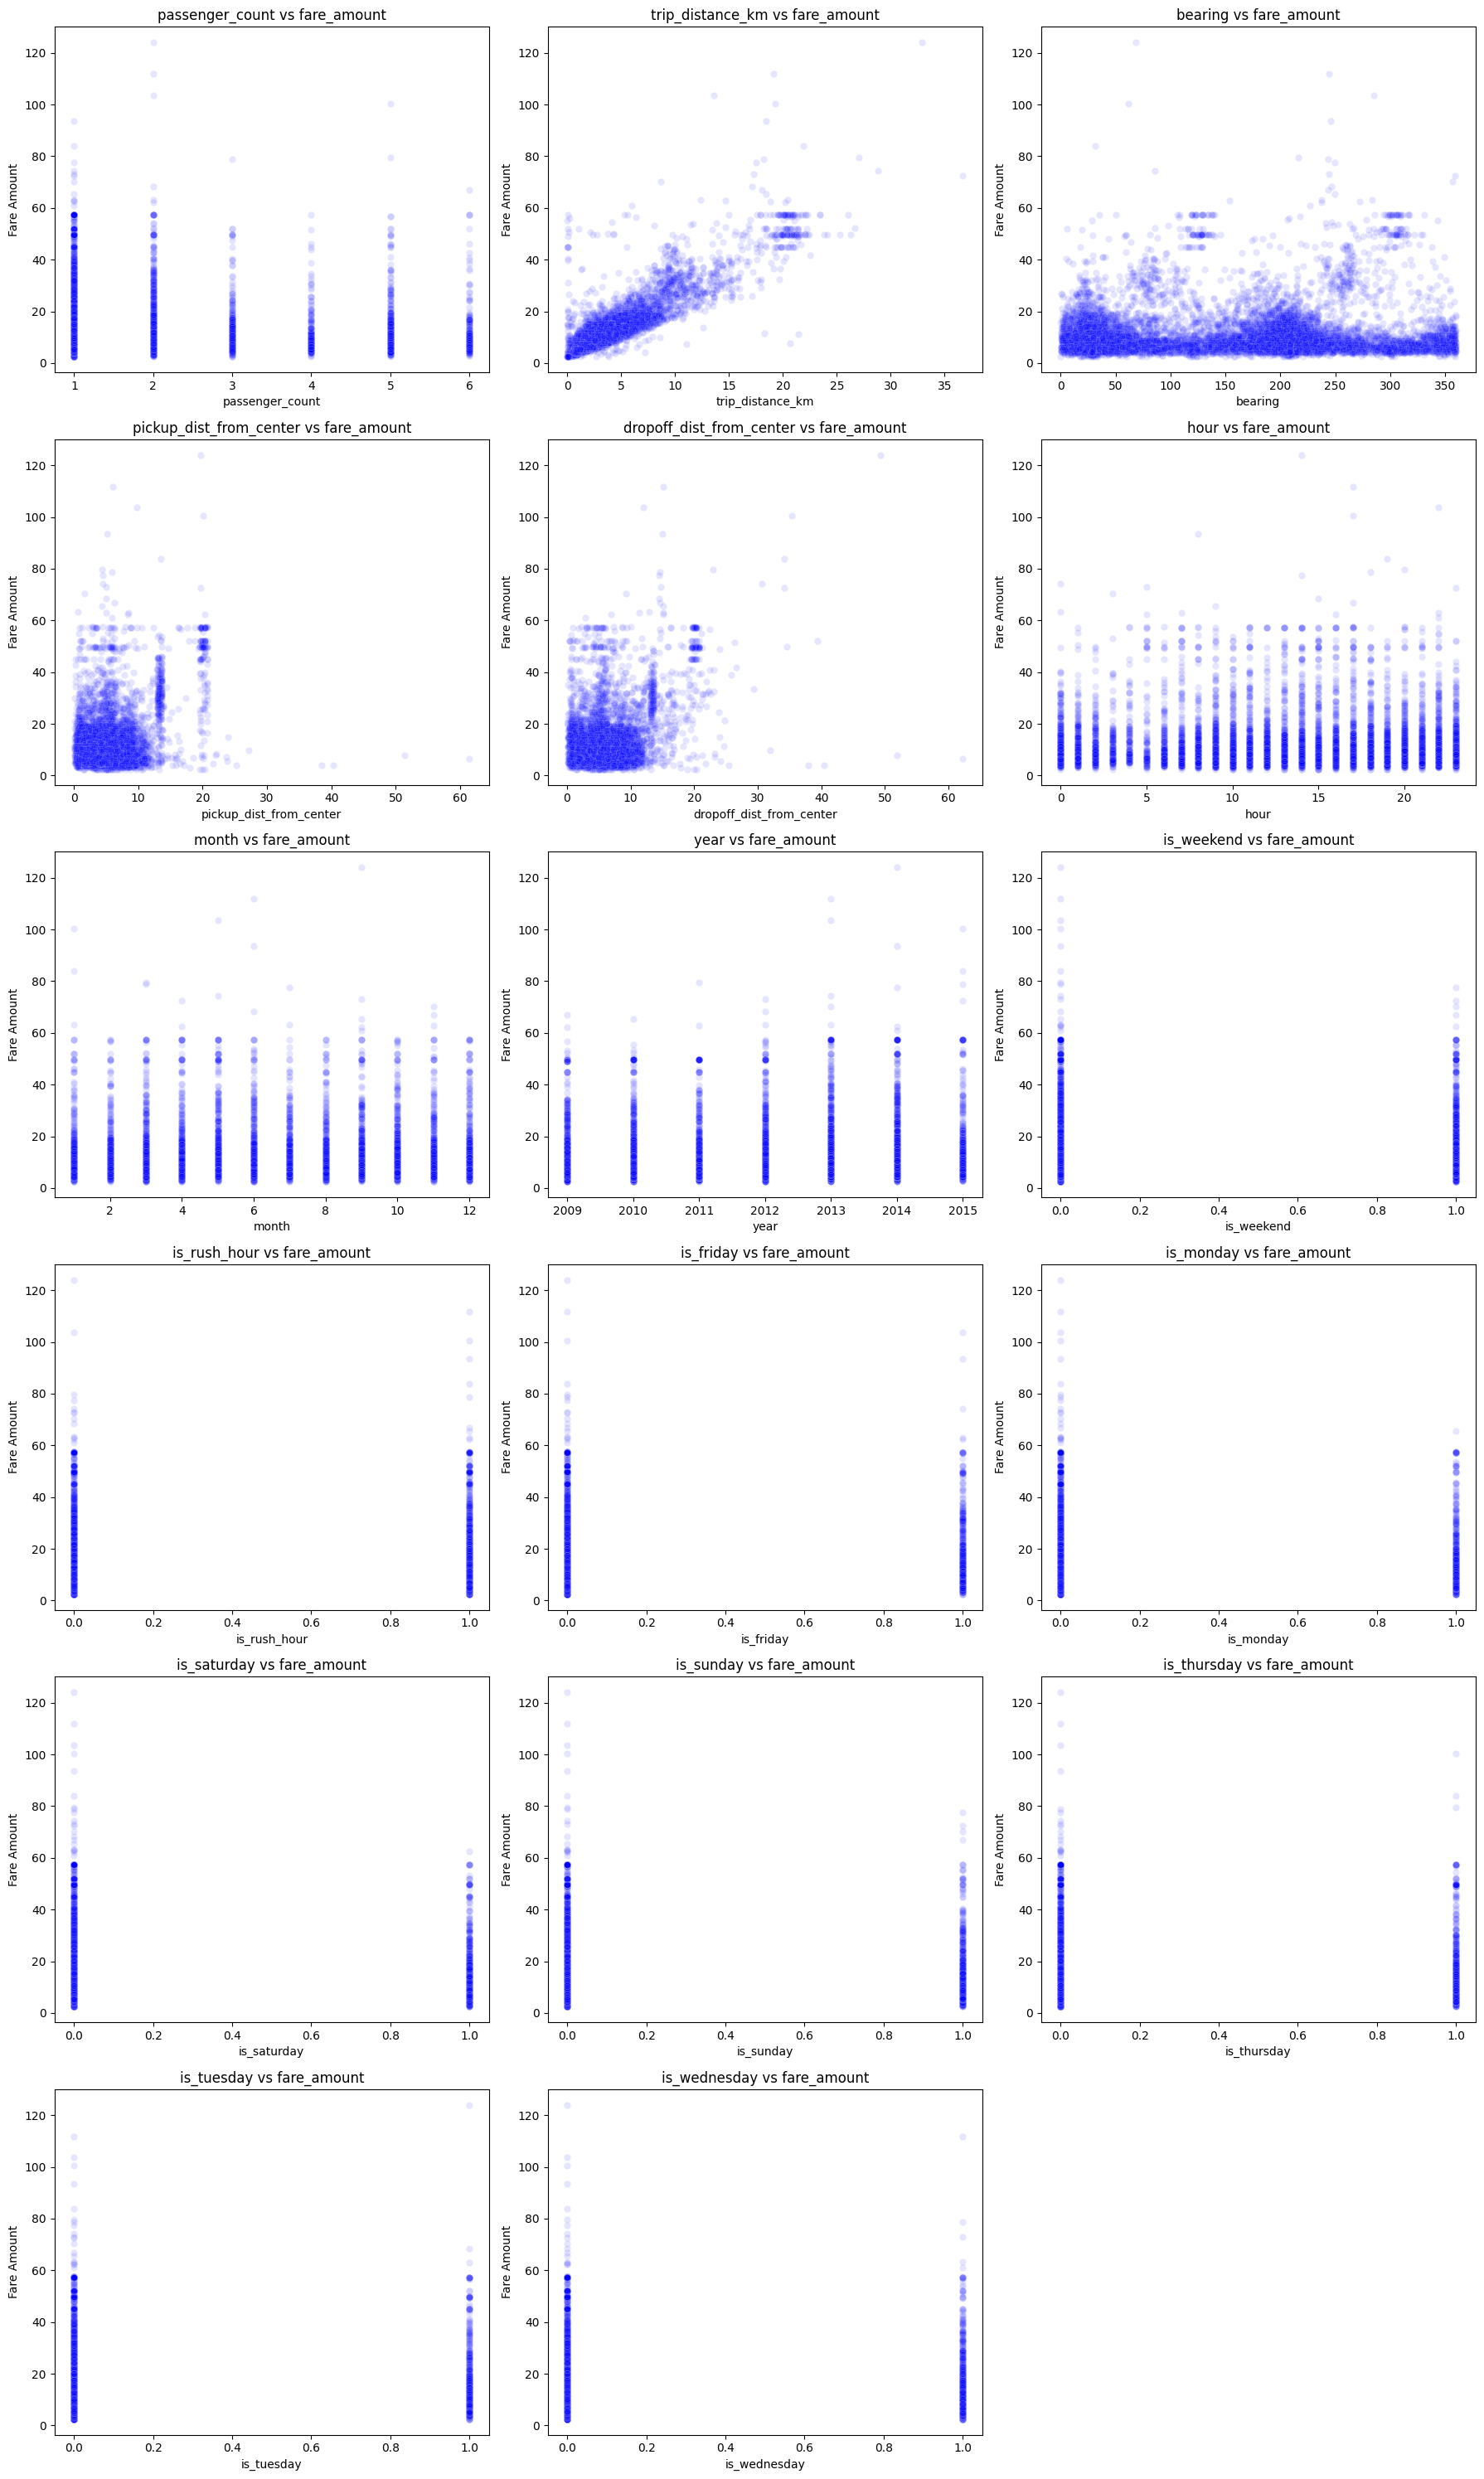

In [6]:
df_sample = df.sample(n=10000, random_state=42) if len(df) > 10000 else df 
target = 'fare_amount'
features = [col for col in df.columns if col != target]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # flatten the 2D array of axes for easy iteration

for i, feature in enumerate(features):
  
    sns.scatterplot(data=df_sample, x=feature, y=target, alpha=0.1, ax=axes[i], color='blue')
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_ylabel('Fare Amount')
    axes[i].set_xlabel(feature)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

dropping a signle day to so that when all days are 0 the model infer that it is that day so we avoid multicolineairty

In [7]:
df = df.drop(columns=['is_sunday'])

****************************************************************************************
****************************************************************************************
SPLITING THE DATA
70% training, 15% validation, 15% test
then scaling the training data so lasso and ridge work well
1 linearRegression model with skitlearn 
and 4 learing models:
 2 for lasso with 2 different lambadas

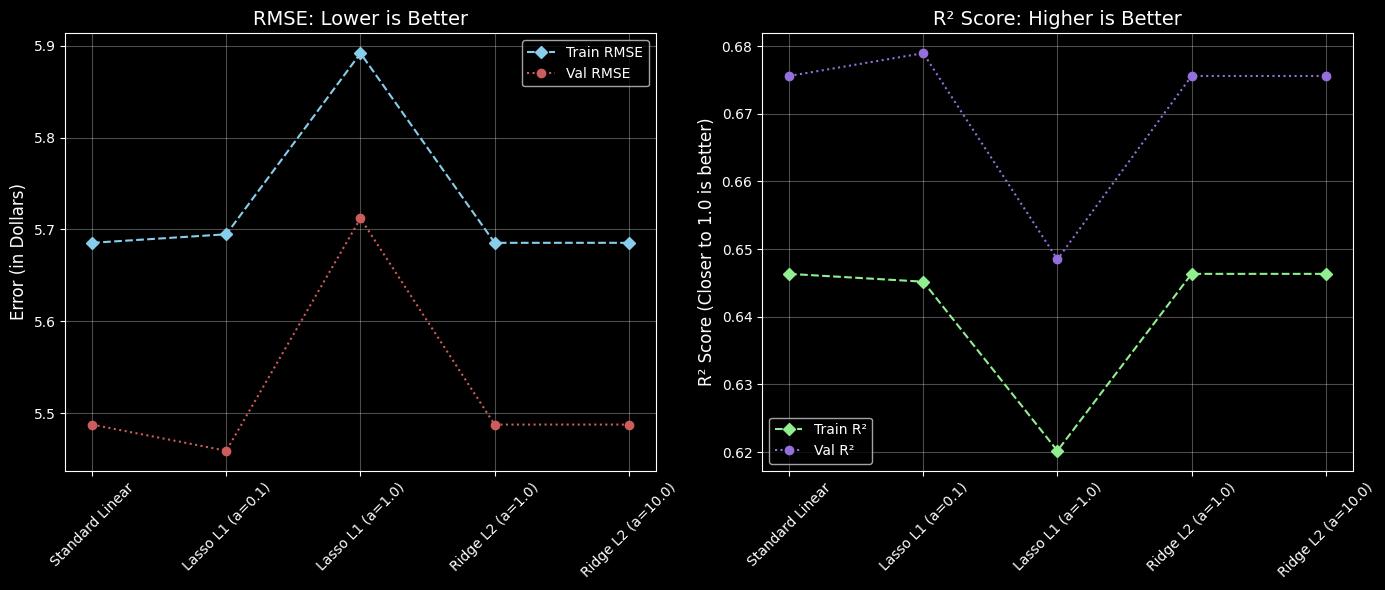


--- Final Validation Scores ---
Standard Linear: RMSE = 5.49 | R² = 0.6756
Lasso L1 (a=0.1): RMSE = 5.46 | R² = 0.6789
Lasso L1 (a=1.0): RMSE = 5.71 | R² = 0.6485
Ridge L2 (a=1.0): RMSE = 5.49 | R² = 0.6756
Ridge L2 (a=10.0): RMSE = 5.49 | R² = 0.6756


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42) #split data into 15 and 85
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42) #split data into 70 and 15

# i need to scale each feature now, it doesnt really matter for linear but for lasso and ridge its essentail

scaler = StandardScaler() # this would rescale each feature to have a mean of 0 and std of 1, min max would also work, scaler is an object
# it has the capabilty of transforming data AND knowing about your data
X_train_scaled = scaler.fit_transform(X_train) #calculates mean and std of features AND stores them in the object  aswell as transforming the features
X_val_scaled = scaler.transform(X_val) ## transforms X_val using the mean/std already stored in scaler
X_test_scaled = scaler.transform(X_test) ## transforms X_val using the mean/std already stored in scaler

#know if i call scaler.mean it gives me an array of means per column, so that i use the means and stds of the training to calucalte future
# data, not try to cheat the test and put the fututre data means in my training


#for easier access we implement a dictionary of words with the coressponding models 
models = {
    "Standard Linear": LinearRegression(),
    "Lasso L1 (a=0.1)": Lasso(alpha=0.1, random_state=42),
    "Lasso L1 (a=1.0)": Lasso(alpha=1.0, random_state=42),
    "Ridge L2 (a=1.0)": Ridge(alpha=1.0, random_state=42),
    "Ridge L2 (a=10.0)":Ridge(alpha=10.0, random_state=42)
}

#we use thoes models to calculate results per model after training 
train_rmse_list = [] # would have training [rmse of linear, rmse of lasso1, rmse of lasso2 , rmse of ridge1 ... }
val_rmse_list = [] # would have val .................
train_r2_list = []
val_r2_list = []

model_names = list(models.keys()) # model.keys gets us the strings we saved above like : 'Standard Linear', 'Lasso L1'.. and so on
# list converts thos keys into an actual python listtt that we save under the name model_names ( no shit )

for name, model in models.items():

    #models.itmes gets you in a signle iteration : 'Standard Linear' -> LinearRegression()
    model.fit(X_train_scaled, y_train)

    #smae as  LinearRegression().fit(X_train_scaled, y_train) at each iteration of
    
    train_preds = model.predict(X_train_scaled)
    val_preds = model.predict(X_val_scaled)
    
 
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)
    
    train_rmse_list.append(train_rmse)
    val_rmse_list.append(val_rmse)
    train_r2_list.append(train_r2)
    val_r2_list.append(val_r2)
plt.style.use('dark_background')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# quite AI assited this part im not good with matplotlib
ax1.plot(model_names, train_rmse_list, label='Train RMSE', marker='D', color='skyblue', linestyle='--')
ax1.plot(model_names, val_rmse_list, label='Val RMSE', marker='o', color='indianred', linestyle=':')
ax1.set_title('RMSE: Lower is Better', fontsize=14)
ax1.set_ylabel('Error (in Dollars)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(model_names, train_r2_list, label='Train R²', marker='D', color='lightgreen', linestyle='--')
ax2.plot(model_names, val_r2_list, label='Val R²', marker='o', color='mediumpurple', linestyle=':')
ax2.set_title('R² Score: Higher is Better', fontsize=14)
ax2.set_ylabel('R² Score (Closer to 1.0 is better)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- Final Validation Scores ---")
for i in range(len(model_names)):
    print(f"{model_names[i]}: RMSE = {val_rmse_list[i]:.2f} | R² = {val_r2_list[i]:.4f}")




it is clear that the lasso (a = 0.1 ) outperfoms the rest, lets now test it on the test data

In [10]:
best_model = models["Lasso L1 (a=0.1)"]

test_preds = best_model.predict(X_test_scaled)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

print(f"Final Test Performance — Lasso (a=0.1)")
print(f"Test RMSE = {test_rmse:.2f} | Test R² = {test_r2:.4f}")

Final Test Performance — Lasso (a=0.1)
Test RMSE = 5.21 | Test R² = 0.6894


the model is off by 5.21 dollar on average, and explains about 69% of the variance in the fare amount of the given features, not bad but not excpetional, will have to test other models.   